In [1]:
print("HELLO DA")

HELLO DA


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\AI-Powered-Customer-Retention-Intelligence-Platform


In [4]:
from src.analysis.eda_loader import load_cleaned_data

print("EDA loader imported successfully.")

EDA loader imported successfully.


In [5]:
datasets = load_cleaned_data()

print("Cleaned datasets loaded successfully.")

Cleaned datasets loaded successfully.


In [6]:
orders = datasets["orders"]

print(orders.shape)

(99441, 8)


In [7]:
orders = datasets["orders"]

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [8]:
order_status = orders["order_status"].value_counts()

order_status

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

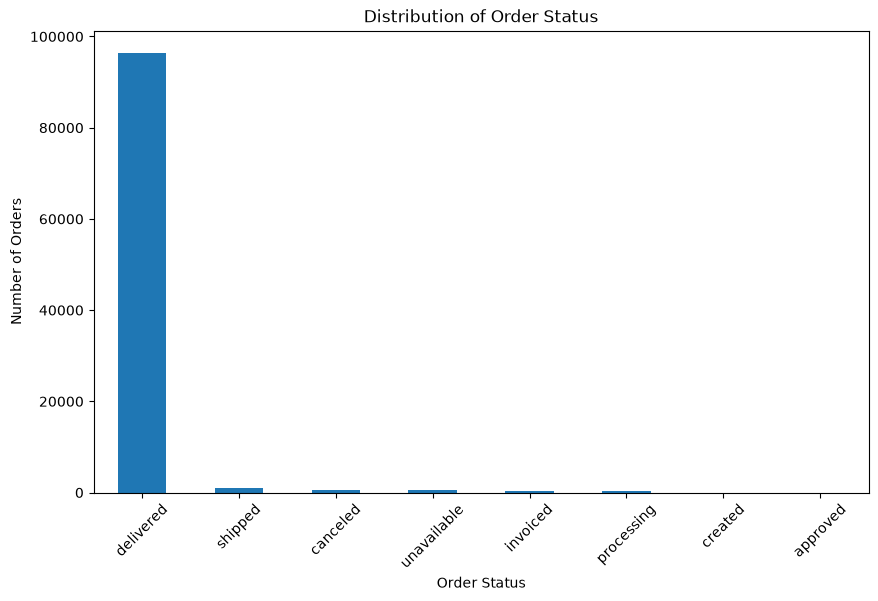

In [9]:
plt.figure(figsize=(10,6))

order_status.plot(kind="bar")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [10]:
reviews = datasets["reviews"]

print(reviews.shape)

reviews.head()

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [11]:
review_counts = reviews["review_score"].value_counts().sort_index()

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

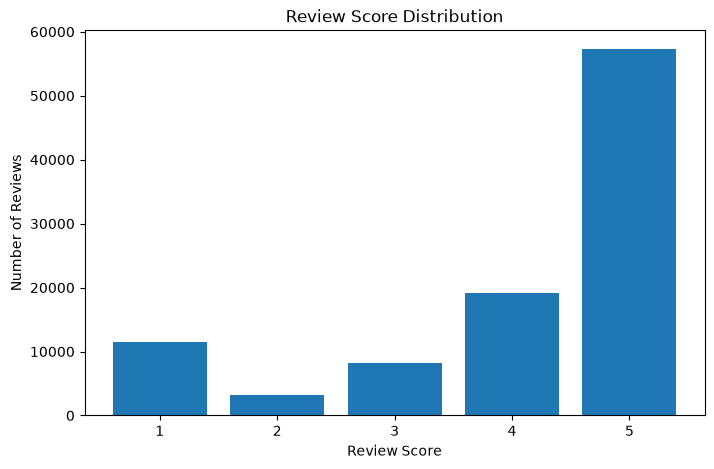

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(review_counts.index.astype(str), review_counts.values)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [13]:
payments = datasets["payments"]

print(payments.shape)
payments.head()

(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [14]:
payment_counts = payments["payment_type"].value_counts()

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

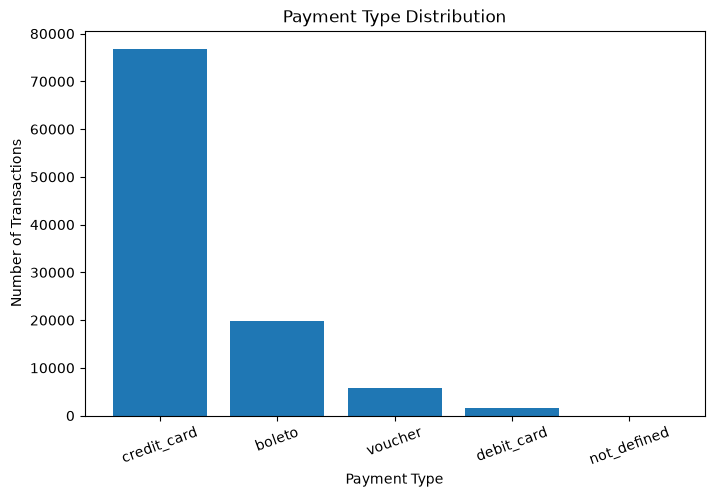

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(payment_counts.index, payment_counts.values)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)

plt.show()

In [16]:
order_items = datasets["order_items"]

print(order_items.shape)

order_items.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017,199.90,18.14


In [17]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

C:\Users\sowmy\AppData\Local\Temp\ipykernel_6196\2273743575.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(order_items["price"], vert=False)


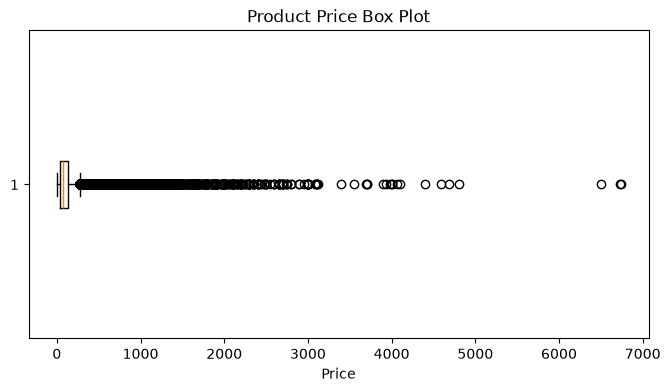

In [18]:
plt.figure(figsize=(8,4))

plt.boxplot(order_items["price"], vert=False)

plt.title("Product Price Box Plot")

plt.xlabel("Price")

plt.show()

FREIGHT VALUE SUMMARY
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


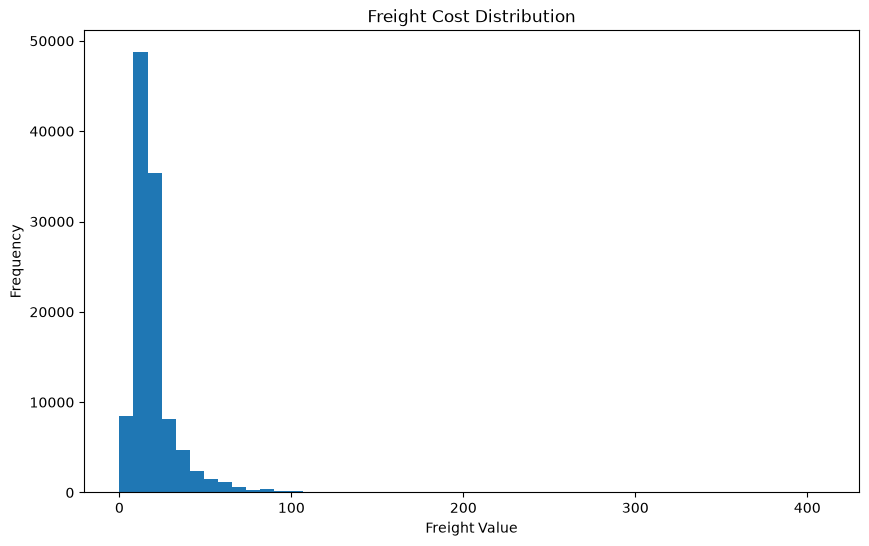

C:\Users\sowmy\AppData\Local\Temp\ipykernel_6196\4137171894.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(order_items["freight_value"], vert=False)


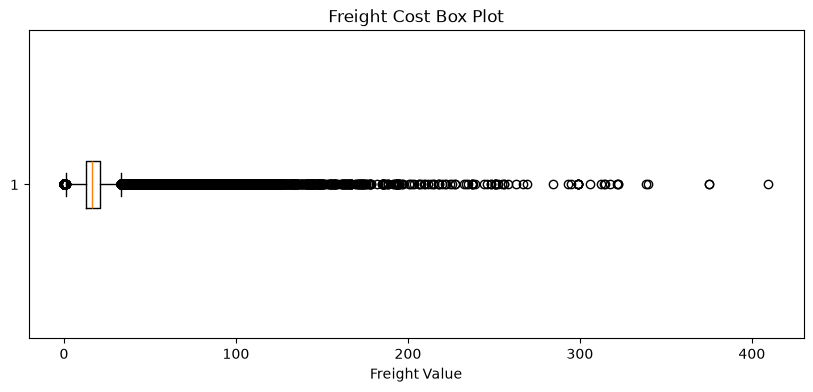

In [19]:
import matplotlib.pyplot as plt

# Load Dataset
order_items = datasets["order_items"]

# Summary Statistics
print("=" * 60)
print("FREIGHT VALUE SUMMARY")
print("=" * 60)
print(order_items["freight_value"].describe())

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(order_items["freight_value"], bins=50)

plt.title("Freight Cost Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")

plt.show()

# Box Plot
plt.figure(figsize=(10, 4))
plt.boxplot(order_items["freight_value"], vert=False)

plt.title("Freight Cost Box Plot")
plt.xlabel("Freight Value")

plt.show()

MONTHLY ORDERS
   Year_Month  Total_Orders
0     2016-09             4
1     2016-10           324
2     2016-12             1
3     2017-01           800
4     2017-02          1780
5     2017-03          2682
6     2017-04          2404
7     2017-05          3700
8     2017-06          3245
9     2017-07          4026
10    2017-08          4331
11    2017-09          4285
12    2017-10          4631
13    2017-11          7544
14    2017-12          5673
15    2018-01          7269
16    2018-02          6728
17    2018-03          7211
18    2018-04          6939
19    2018-05          6873
20    2018-06          6167
21    2018-07          6292
22    2018-08          6512
23    2018-09            16
24    2018-10             4


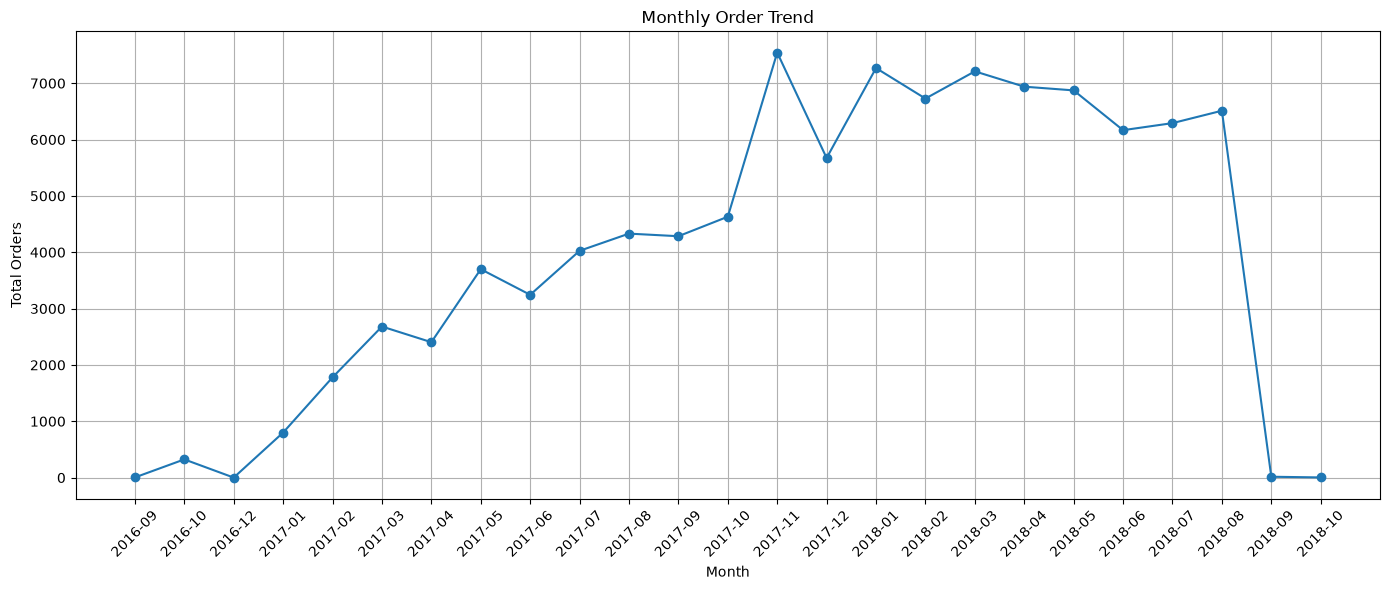

In [20]:
# ==========================================================
# EDA - Monthly Orders Trend
# Business Question:
# How has customer order volume changed over time?
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
orders = datasets["orders"].copy()

# Convert Purchase Timestamp to Datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Create Year-Month Column
orders["Year_Month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly Orders
monthly_orders = (
    orders.groupby("Year_Month")
    .size()
    .reset_index(name="Total_Orders")
)

print("=" * 60)
print("MONTHLY ORDERS")
print("=" * 60)
print(monthly_orders)

# Line Chart
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["Year_Month"],
    monthly_orders["Total_Orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

MONTHLY REVENUE
   Year_Month  payment_value
0     2016-09         252.24
1     2016-10       59090.48
2     2016-12          19.62
3     2017-01      138488.04
4     2017-02      291908.01
5     2017-03      449863.60
6     2017-04      417788.03
7     2017-05      592918.82
8     2017-06      511276.38
9     2017-07      592382.92
10    2017-08      674396.32
11    2017-09      727762.45
12    2017-10      779677.88
13    2017-11     1194882.80
14    2017-12      878401.48
15    2018-01     1115004.18
16    2018-02      992463.34
17    2018-03     1159652.12
18    2018-04     1160785.48
19    2018-05     1153982.15
20    2018-06     1023880.50
21    2018-07     1066540.75
22    2018-08     1022425.32
23    2018-09        4439.54
24    2018-10         589.67


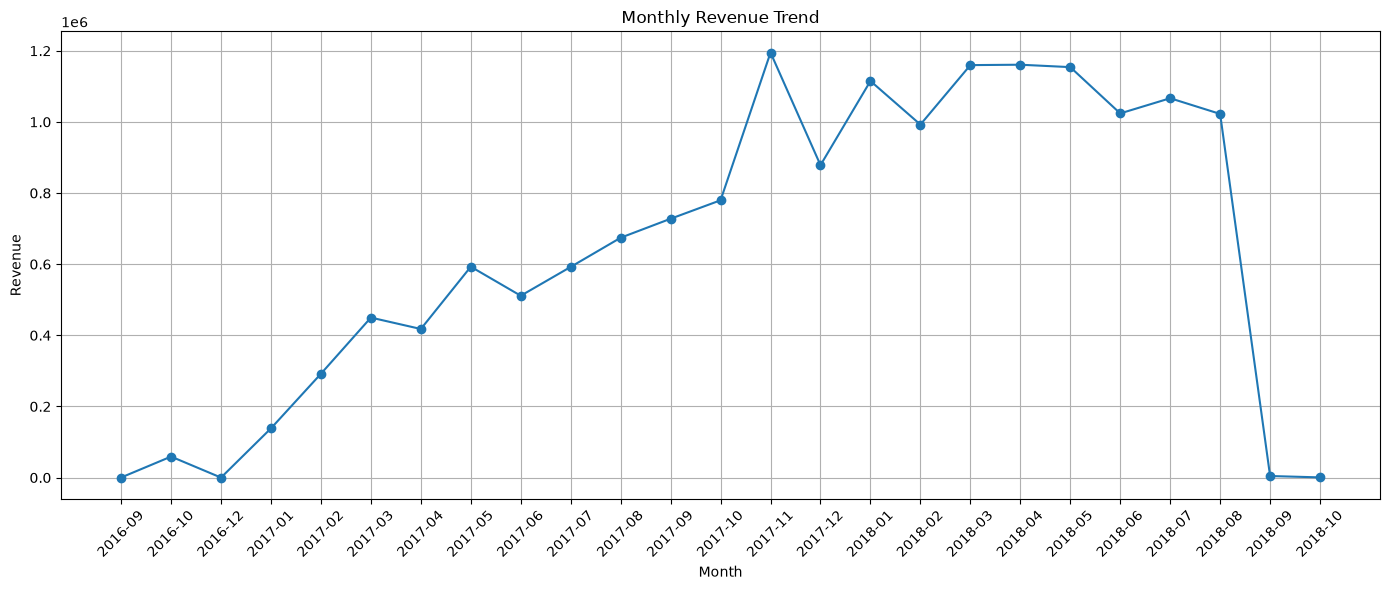

In [21]:
# ==========================================================
# EDA - Monthly Revenue Trend
# Business Question:
# How has monthly revenue changed over time?
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Datasets
orders = datasets["orders"].copy()
payments = datasets["payments"].copy()

# Convert Purchase Timestamp
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Merge Orders and Payments
revenue = orders.merge(
    payments,
    on="order_id",
    how="inner"
)

# Create Year-Month Column
revenue["Year_Month"] = (
    revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly Revenue
monthly_revenue = (
    revenue.groupby("Year_Month")["payment_value"]
    .sum()
    .reset_index()
)

print("=" * 60)
print("MONTHLY REVENUE")
print("=" * 60)
print(monthly_revenue)

# Plot
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["payment_value"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

TOP 10 PRODUCT CATEGORIES
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


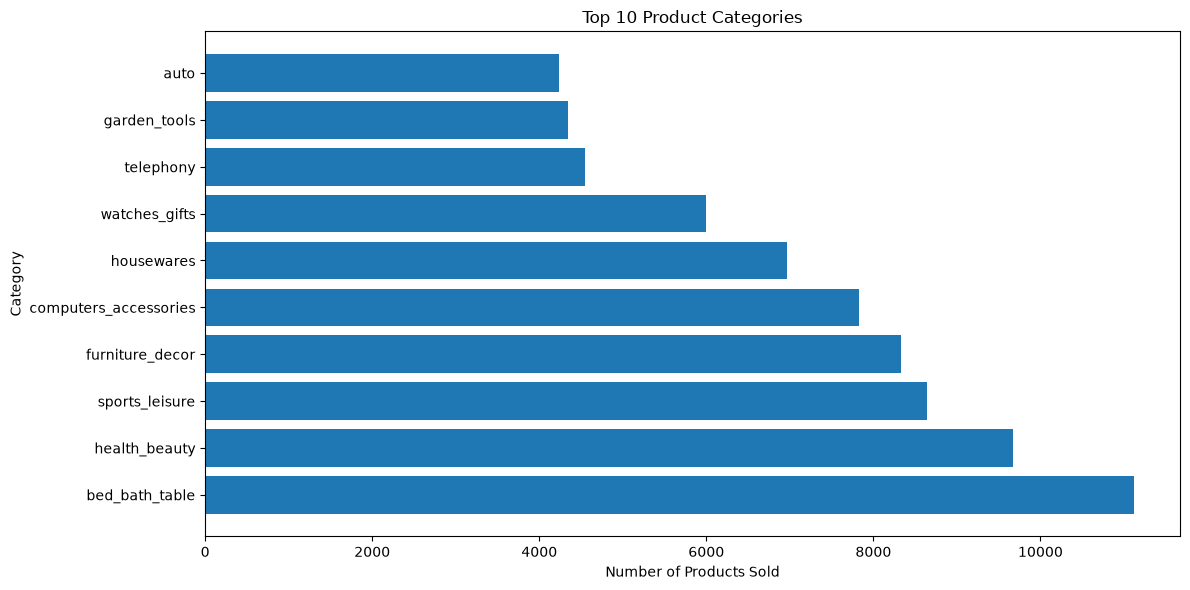

In [22]:
# ==========================================================
# EDA - Top Product Categories
# Business Question:
# Which product categories are sold the most?
# ==========================================================

import matplotlib.pyplot as plt

# Load Datasets
order_items = datasets["order_items"].copy()
products = datasets["products"].copy()
translation = datasets["translation"].copy()

# Merge Products with Translation
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

# Merge Order Items with Products
category_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

# Count Sales by Category
top_categories = (
    category_sales["product_category_name_english"]
    .value_counts()
    .head(10)
)

print("=" * 60)
print("TOP 10 PRODUCT CATEGORIES")
print("=" * 60)
print(top_categories)

# Plot
plt.figure(figsize=(12,6))

plt.barh(
    top_categories.index,
    top_categories.values
)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products Sold")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

TOP 10 CUSTOMER STATES
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


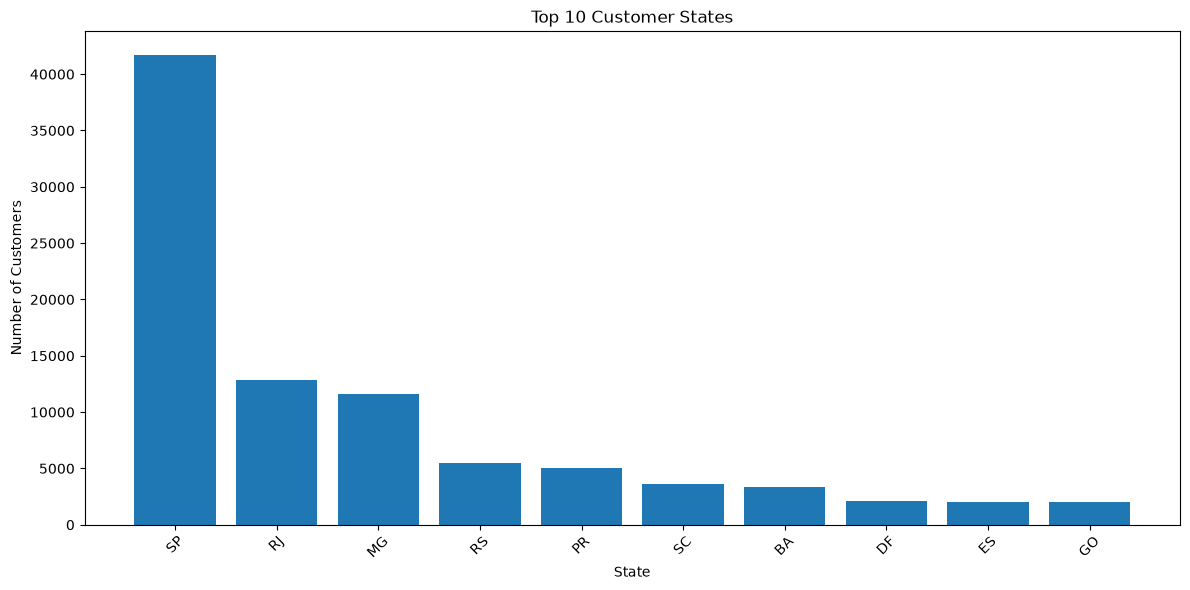

In [23]:
# ==========================================================
# EDA - Customer State Distribution
# Business Question:
# Which states have the highest number of customers?
# ==========================================================

import matplotlib.pyplot as plt

# Load Dataset
customers = datasets["customers"].copy()

# Count Customers by State
state_counts = (
    customers["customer_state"]
    .value_counts()
    .head(10)
)

print("=" * 60)
print("TOP 10 CUSTOMER STATES")
print("=" * 60)
print(state_counts)

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    state_counts.index,
    state_counts.values
)

plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

DELIVERY TIME SUMMARY
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


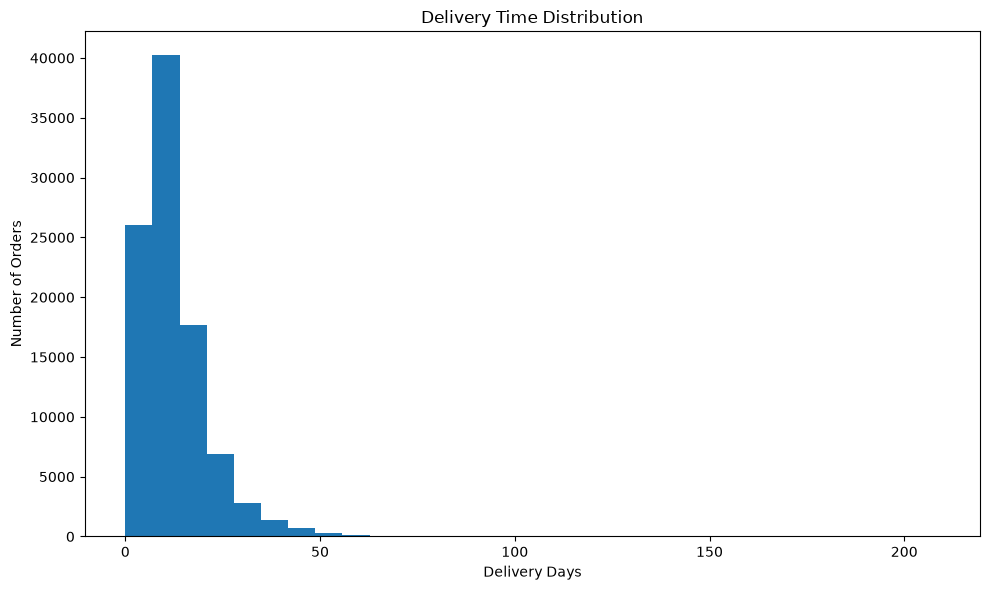

C:\Users\sowmy\AppData\Local\Temp\ipykernel_6196\4028329370.py:57: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


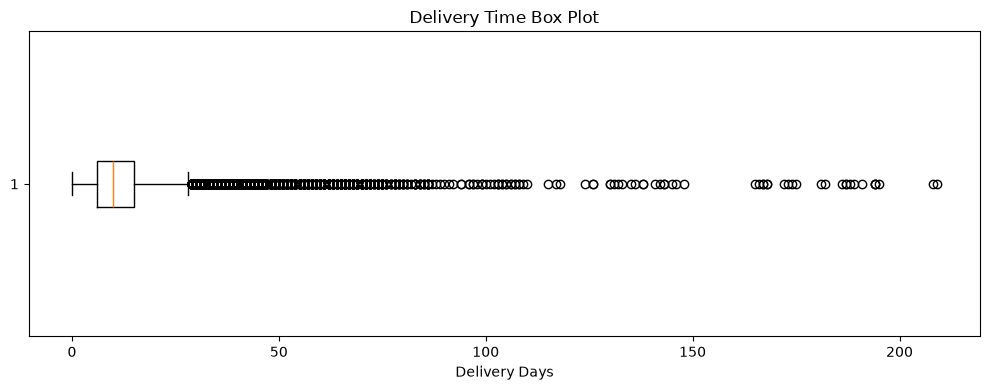

In [24]:
# ==========================================================
# EDA - Delivery Time Analysis
# Business Question:
# How long does it take to deliver customer orders?
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

# Load Dataset
orders = datasets["orders"].copy()

# Convert to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

# Keep only delivered orders
delivery = orders.dropna(
    subset=["order_delivered_customer_date"]
).copy()

# Calculate Delivery Days
delivery["delivery_days"] = (
    delivery["order_delivered_customer_date"]
    - delivery["order_purchase_timestamp"]
).dt.days

print("=" * 60)
print("DELIVERY TIME SUMMARY")
print("=" * 60)
print(delivery["delivery_days"].describe())

# Histogram
plt.figure(figsize=(10,6))

plt.hist(
    delivery["delivery_days"],
    bins=30
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

# Box Plot
plt.figure(figsize=(10,4))

plt.boxplot(
    delivery["delivery_days"],
    vert=False
)

plt.title("Delivery Time Box Plot")
plt.xlabel("Delivery Days")

plt.tight_layout()

plt.show()

CORRELATION MATRIX
                  price  freight_value  payment_value  review_score
price          1.000000       0.413095       0.995968     -0.039673
freight_value  0.413095       1.000000       0.492996     -0.088663
payment_value  0.995968       0.492996       1.000000     -0.046667
review_score  -0.039673      -0.088663      -0.046667      1.000000


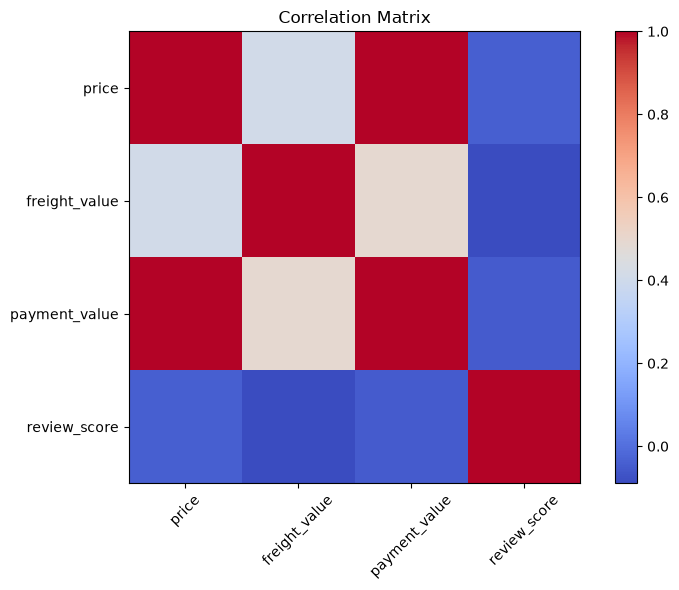

In [25]:
# ==========================================================
# EDA - Correlation Analysis
# Business Question:
# Are there relationships between important numerical variables?
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Datasets
order_items = datasets["order_items"].copy()
payments = datasets["payments"].copy()
reviews = datasets["reviews"].copy()

# Aggregate Payment Value per Order
payment_summary = (
    payments.groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

# Aggregate Order Item Information per Order
order_summary = (
    order_items.groupby("order_id")
    .agg({
        "price": "sum",
        "freight_value": "sum"
    })
    .reset_index()
)

# Merge Datasets
corr_df = (
    order_summary
    .merge(payment_summary, on="order_id", how="inner")
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

# Correlation Matrix
correlation = corr_df[
    ["price", "freight_value", "payment_value", "review_score"]
].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
print(correlation)

# Plot Correlation Matrix
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()